# Week 7: Model Evaluation 🔍
# Additional Exercises

This notebook builds on Week 6's Additional Exercises. If you haven't already, you should complete the model training in that week first before continuing this exercise. In this notebook, you will apply the metrics you learned about to evaluate the model you trained in Week 6's Additional Exercises. Below we have imported the necessary modules/packages and split the data the same way as in Week 6. Run the code below for setup.

In [13]:
# SETUP CODE - DO NOT MODIFY
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("./Heart Failure Clinical Records.csv")

target = df["DEATH_EVENT"]

# Removing time due to target leakage
predictors = df.drop(['DEATH_EVENT', 'time'], axis = 1)

# Split the dataset into training and testing.
train_inputs, test_inputs, train_targets, test_targets = train_test_split(predictors, target, test_size = 0.20, shuffle = True, random_state=7)

# Scaling the features
sc = StandardScaler()
train_scaled = sc.fit_transform(train_inputs.astype(float, 64))
test_scaled = sc.transform(test_inputs.astype(float, 64))
test_scaled = pd.DataFrame(test_scaled, columns=train_inputs.columns)
train_scaled = pd.DataFrame(train_scaled, columns=test_inputs.columns)

# to keep naming consistent (can use ether variable)
train_inputs = train_scaled
test_inputs = test_scaled

At this point you need to load your own trained heart failure model from the Week 6 Additional Exercise. If you haven't done so already, go into Week 6 and save that model, then return to this notebook when you are done. If you have already saved the model in that module, copy the .pkl file into the Week 7 folder (same folder that this notebook is in).

Once your model file is in this folder, complete the code below to load it. Refer to the pre-module in Week 6 on how to do this using ```pickle```.

<span style="background-color: #FFD700">**Write your code below**</span>

In [14]:
import pickle

# Load the trained week 6 model
with open('hf_model.pkl', 'rb') as file:
    model = pickle.load(file)

**Complete the code in the markdwon cell below, much like in week 7's tutorial, to generate the metrics.** Try to do this without copying everything directly from the tutorial notebook!

Some tips:
1. Before you start writing code, think about what you need to obtain as the end result and work backwards to identify what intermediate stages you need. 
2. Write comments in the code as you develop, to keep track of your process.
3. Look up functions/explanations on the sci-kit learn documentation: https://scikit-learn.org/stable/modules/classes.html 
    * note: there are many functions on the website. It may be useful to search for a specific one by using ctrl+F/cmd+F or using the search bar. 
4. Look up what functions/procedures could help you achieve what you need on google, stackoverflow, etc. See Week 1 Additional Exercises for reference. 

Heart Failure Classifier: LogisticRegression

Evaluation metrics:
 Accuracy     0.816667
Precision    0.666667
Recall       0.428571
F1-Score     0.521739
dtype: float64


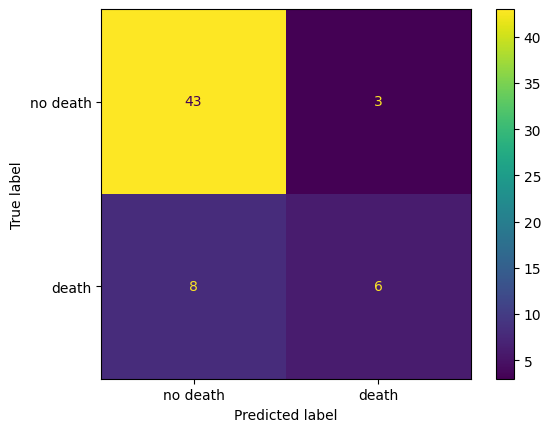

In [15]:
# import sklearn metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# get model predictions
# Prediction
preds = model.predict(test_inputs)


acc = accuracy_score(test_targets, preds)
precision = precision_score(test_targets, preds)
recall = recall_score(test_targets, preds)
f1 = f1_score(test_targets, preds)
conf = confusion_matrix(test_targets, preds)

labels = np.where(model.classes_, 'death', 'no death')
display = ConfusionMatrixDisplay(confusion_matrix=conf,
                                display_labels=labels)

eval = pd.Series({
    "Accuracy": acc,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
})

print(f"Heart Failure Classifier: LogisticRegression")
print(f"\nEvaluation metrics:\n",eval)

display.plot()

## Discussion

<span style="background-color: #FFD700">**Based on the results you obtained above, answer the following questions.**</span>

**Q1. Is the dataset imbalanced?**

**Q2. Which metrics would you say are most important for evaluating this particular model? Explain your reasoning.**

**Q3. Is there any underfitting/overfitting? How can you tell?**

**Q4. Would you say the model generalizes well? Why or why not?**

**Q5. If there are any signs of poor performance (underitting/overfitting/low accuracy/low precision etc.), list some things you would try to improve each issue.**


## Conclusion

This concludes the practice exercises using the heart failure dataset. Congratulations! From the additional exercises in week 6 and 7, you have implement a machine learning pipeline yourself to train and evaluate a heart failure death prediction model. You have learned how to use the sci-kit learn library to implement this pipeline, seen some common pitfalls along the way, and learned how to interpret the results.

This is only the beginning of your exploration in machine learning! You will discover much more as you continue your learning journey, including different models, training techniques, evaluation methods, data cleaning techniques, and more. You will see a brief review of different models next week to hopefully spark your interest in this vast and evergrowing field.